# Original NetAn Enrichment Analysis

# Overview

This notebook reproduces the original NetAn enrichment analysis performed on the curated breast cancer-associated gene set.

The analysis evaluates functional enrichment using:

- Gene Ontology (GO) annotations
- KEGG pathways

The original breast cancer gene set was analysed using the NetAn enrichment workflow before network expansion and topology-driven clustering.

Statistical significance was assessed using an adjusted p-value threshold of 0.05.

In [1]:

import os
import sys
import numpy as np
import pandas as pd

sys.path.append(".")
sys.path.append("source")
sys.path.append("utilities")

from utilities.enrich_utils import calc_enrich

print("Imports ready")

Imports ready


In [2]:
# Load the original curated breast cancer gene set

from pathlib import Path

PROJECT_ROOT = Path.cwd()

gene_file = PROJECT_ROOT / "data" / "raw" / "unique_genes_clean.csv"

genes_df = pd.read_csv(gene_file, header=None)

genes = (
    genes_df.iloc[:, 0]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
    .tolist()
)

print("Original breast cancer genes loaded:", len(genes))
print("First 10 genes:", genes[:10])

Original breast cancer genes loaded: 997
First 10 genes: ['AARSD1', 'AASDHPPT', 'AATF', 'ABCB6', 'ABCC3', 'ABI3', 'ACACA', 'ACADVL', 'ACAP1', 'ACAT1']


# 1. Gene Ontology Enrichment

Gene Ontology enrichment was performed using the original NetAn enrichment workflow.

Only annotations meeting the adjusted p-value significance threshold of < 0.05 are considered statistically significant.

In [3]:
# Original NetAn GO enrichment

pure_go = calc_enrich(
    genes=genes,
    annotations="GO",
    thresh=5,
    ngenes_background=22000
)

pure_go["source"] = "Pure_NetAn_GO"

print("Pure NetAn GO enrichment completed")
print("Total GO terms:", len(pure_go))
print("Significant GO terms:", (pure_go["p_adj"] < 0.05).sum())

display(pure_go.head(10))

Calculating Fisher test
Pure NetAn GO enrichment completed
Total GO terms: 6857
Significant GO terms: 54


,OR,pval,p_adj,genes,source
keratin filament,12.764001,5.958085e-25,4.085459e-21,"KRT10, KRT13, KRT14, KRT16, KRT25, KRT36, KRT9...",Pure_NetAn_GO
intermediate filament organization,14.085007,1.171831e-19,4.017623e-16,"GFAP, KRT10, KRT12, KRT13, KRT14, KRT15, KRT16...",Pure_NetAn_GO
epithelial cell differentiation,9.361416,1.211137e-16,2.768257e-13,"ACADVL, DLX3, KRT10, KRT12, KRT13, KRT14, KRT1...",Pure_NetAn_GO
intermediate filament,5.937671,9.677196e-12,1.658913e-08,"GFAP, JUP, KRT10, KRT12, KRT14, KRT15, KRT16, ...",Pure_NetAn_GO
hair cycle,53.188956,2.965156e-11,4.066415e-08,"KRT14, KRT16, KRT25, KRT33B, KRTAP4-3, KRTAP4-...",Pure_NetAn_GO
structural molecule activity,4.119247,1.597344e-09,1.825498e-06,"CLDN7, CRYAB, CTNNA1, JUP, KRT12, KRT13, KRT17...",Pure_NetAn_GO
CCR chemokine receptor binding,13.289640,9.559206e-08,9.363925e-05,"CCL14, CCL15, CCL16, CCL18, CCL23, CCL3, CCL3L...",Pure_NetAn_GO
four-way junction DNA binding,15.934464,1.396531e-07,1.197001e-04,"BLM, FANCM, MEN1, MSH2, MSH6, RAD51C, RAD51D, ...",Pure_NetAn_GO
double-strand break repair via homologous recombination,4.602635,1.598805e-07,1.218112e-04,"ATM, BLM, BRCA1, BRCA2, ERCC4, KDM4D, MBTD1, M...",Pure_NetAn_GO
"chromosome, telomeric region",3.702382,3.520169e-07,2.413780e-04,"ATM, ATR, BLM, BRCA2, CBX1, CDC73, CHEK2, CTC1...",Pure_NetAn_GO


# 2. KEGG Pathway Enrichment

KEGG pathway enrichment was performed using the same original breast cancer gene set and NetAn enrichment workflow.

Statistical significance was assessed using an adjusted p-value threshold of < 0.05.

In [4]:
# Original NetAn KEGG enrichment

pure_kegg = calc_enrich(
    genes=genes,
    annotations="KEGG",
    thresh=5,
    ngenes_background=22000
)

pure_kegg["source"] = "Pure_NetAn_KEGG"

print("Pure NetAn KEGG enrichment completed")
print("Total KEGG terms:", len(pure_kegg))
print("Significant KEGG terms:", (pure_kegg["p_adj"] < 0.05).sum())

display(pure_kegg.head(10))

Calculating Fisher test
Pure NetAn KEGG enrichment completed
Total KEGG terms: 345
Significant KEGG terms: 24


,OR,pval,p_adj,genes,source
Estrogen signaling pathway,7.382476,3.998365e-17,1.379436e-14,"AKT1, EGFR, JUN, KRAS, KRT10, KRT12, KRT13, KR...",Pure_NetAn_KEGG
Staphylococcus aureus infection,8.323873,1.312542e-14,2.264136e-12,"KRT10, KRT12, KRT13, KRT14, KRT15, KRT16, KRT1...",Pure_NetAn_KEGG
Fanconi anemia pathway,12.625083,8.220129e-14,9.453149e-12,"ATR, BLM, BRCA1, BRCA2, BRIP1, EME1, ERCC4, FA...",Pure_NetAn_KEGG
Homologous recombination,15.163393,6.800860e-13,5.865742e-11,"ATM, BARD1, BLM, BRCA1, BRCA2, BRIP1, EME1, MR...",Pure_NetAn_KEGG
Endometrial cancer,6.633028,2.777663e-07,1.916587e-05,"AKT1, APC, AXIN2, BRAF, CDH1, CTNNA1, CTNNA2, ...",Pure_NetAn_KEGG
Gastric cancer,3.481653,4.259902e-06,2.449443e-04,"AKT1, APC, AXIN2, BRAF, CDH1, CDKN1B, CDKN2B, ...",Pure_NetAn_KEGG
Non-small cell lung cancer,4.611433,2.165829e-05,9.898789e-04,"AKT1, BRAF, CDKN2A, EGFR, ERBB2, FHIT, KRAS, P...",Pure_NetAn_KEGG
Chemokine signaling pathway,2.893822,2.295371e-05,9.898789e-04,"AKT1, BCAR1, BRAF, CCL14, CCL15, CCL16, CCL18,...",Pure_NetAn_KEGG
FoxO signaling pathway,3.339557,3.225314e-05,1.236371e-03,"AKT1, ATM, BRAF, CDKN1B, CDKN2B, EGFR, G6PC1, ...",Pure_NetAn_KEGG
Breast cancer,3.143625,4.149967e-05,1.320075e-03,"AKT1, APC, AXIN2, BRAF, BRCA1, BRCA2, DVL2, EG...",Pure_NetAn_KEGG


In [6]:
# Save original NetAn GO and KEGG enrichment results

OUTPUT_DIR = PROJECT_ROOT / "results" / "enrichment" / "original_netan"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pure_go.to_csv(
    OUTPUT_DIR / "pure_netan_GO_original_gene_set.csv",
    index=True
)

pure_kegg.to_csv(
    OUTPUT_DIR / "pure_netan_KEGG_original_gene_set.csv",
    index=True
)

# Save significant results separately
pure_go[pure_go["p_adj"] < 0.05].to_csv(
    OUTPUT_DIR / "pure_netan_GO_significant.csv",
    index=True
)

pure_kegg[pure_kegg["p_adj"] < 0.05].to_csv(
    OUTPUT_DIR / "pure_netan_KEGG_significant.csv",
    index=True
)

print("Original NetAn results saved successfully.")
print("Output directory:", OUTPUT_DIR)

Original NetAn results saved successfully.
Output directory: /Users/gorgeous_jane/Documents/GitHub/NetAn-Breast-Cancer-geneset-Analysis/results/enrichment/original_netan


# Original NetAN enrichment summary

The original NetAN analysis identified 54 significantly enriched GO terms and 24 significantly enriched KEGG pathways in the reproducible reconstruction, giving 78 significant annotations in total.

The thesis reported approximately 76 significant GO and KEGG annotations combined. The small difference is retained rather than adjusted manually, ensuring that the GitHub workflow reflects the reproducible computational output.

# 3. Visualization of Original NetAN Enrichment
The original NetAN enrichment results are visualized separately for GO and KEGG.

Only statistically significant annotations (adjusted p < 0.05) are displayed. Bar length represents the odds ratio, while colour intensity represents enrichment significance as −log10(adjusted p-value).

Two complementary visualization approaches are generated.

# Thesis-style visualizations

Figures 3a and 3b reproduce the original NetAN presentation of significant GO and KEGG enrichment. Bar length represents the odds ratio, while colour intensity represents enrichment significance as −log10(adjusted p-value).

# Full reproducible visualizations

Additional plots display all statistically significant GO and KEGG results identified by the reproducible workflow. These provide complete visibility of the enrichment results rather than only the terms selected for presentation.

In [10]:
from pathlib import Path

FIGURE_DIR = PROJECT_ROOT / "figures" / "original_netan"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Figure directory ready:")
print(FIGURE_DIR)

Figure directory ready:
/Users/gorgeous_jane/Documents/GitHub/NetAn-Breast-Cancer-geneset-Analysis/figures/original_netan


In [8]:
# Prepare significant enrichment results for visualization

go_sig = pure_go[pure_go["p_adj"] < 0.05].copy()
kegg_sig = pure_kegg[pure_kegg["p_adj"] < 0.05].copy()

go_sig["neg_log10_padj"] = -np.log10(go_sig["p_adj"])
kegg_sig["neg_log10_padj"] = -np.log10(kegg_sig["p_adj"])

print(f"Significant GO terms: {len(go_sig)}")
print(f"Significant KEGG pathways: {len(kegg_sig)}")

Significant GO terms: 54
Significant KEGG pathways: 24


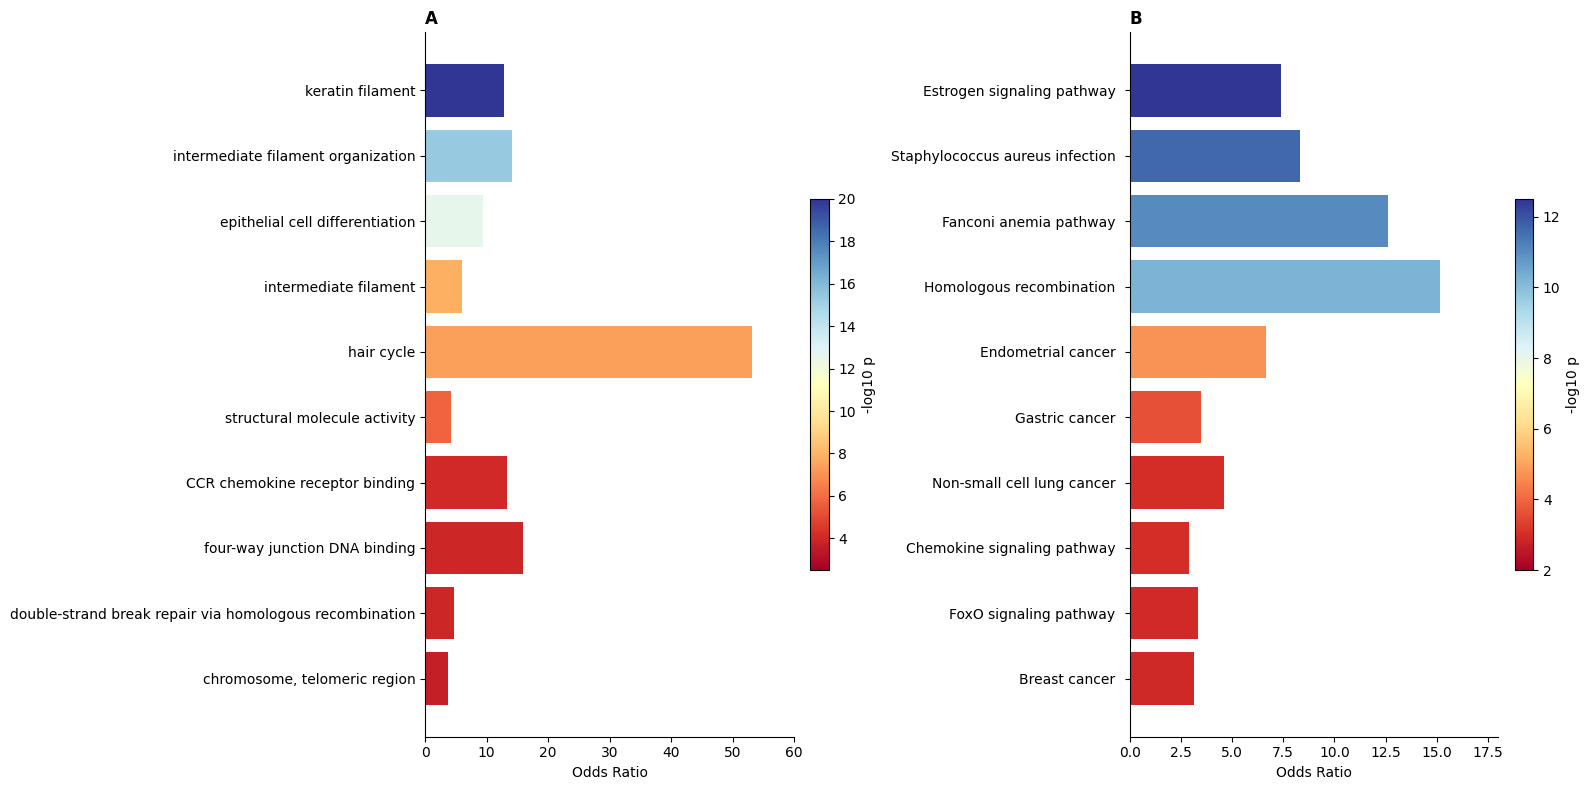

Figure 3 saved successfully:
/Users/gorgeous_jane/Documents/GitHub/NetAn-Breast-Cancer-geneset-Analysis/figures/original_netan/Figure_3_Original_NetAN_GO_KEGG.png


In [12]:
# ============================================================
# Figure 3 — Original NetAN enrichment
# Thesis-style reproduction
# Panel A: GO
# Panel B: KEGG
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Select top 10 significant results
# ------------------------------------------------------------

go_plot = pure_go[pure_go["p_adj"] < 0.05].head(10).copy()
kegg_plot = pure_kegg[pure_kegg["p_adj"] < 0.05].head(10).copy()

go_plot["neg_log10_padj"] = -np.log10(go_plot["p_adj"])
kegg_plot["neg_log10_padj"] = -np.log10(kegg_plot["p_adj"])

# Reverse order for top-to-bottom presentation
go_plot = go_plot.iloc[::-1]
kegg_plot = kegg_plot.iloc[::-1]

# ------------------------------------------------------------
# Figure layout
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 8)
)

# ============================================================
# PANEL A — GO
# ============================================================

ax = axes[0]

go_norm = plt.Normalize(2.5, 20)

go_colors = plt.cm.RdYlBu(
    go_norm(go_plot["neg_log10_padj"])
)

ax.barh(
    go_plot.index,
    go_plot["OR"],
    color=go_colors
)

ax.set_xlabel("Odds Ratio")
ax.set_ylabel("")
ax.set_xlim(0, 60)
ax.set_title("A", loc="left", fontweight="bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

sm_go = plt.cm.ScalarMappable(
    cmap=plt.cm.RdYlBu,
    norm=go_norm
)
sm_go.set_array([])

cbar_go = fig.colorbar(
    sm_go,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

cbar_go.set_label("-log10 p")

# ============================================================
# PANEL B — KEGG
# ============================================================

ax = axes[1]

kegg_norm = plt.Normalize(2, 12.5)

kegg_colors = plt.cm.RdYlBu(
    kegg_norm(kegg_plot["neg_log10_padj"])
)

ax.barh(
    kegg_plot.index,
    kegg_plot["OR"],
    color=kegg_colors
)

ax.set_xlabel("Odds Ratio")
ax.set_ylabel("")
ax.set_xlim(0, 18)
ax.set_title("B", loc="left", fontweight="bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

sm_kegg = plt.cm.ScalarMappable(
    cmap=plt.cm.RdYlBu,
    norm=kegg_norm
)
sm_kegg.set_array([])

cbar_kegg = fig.colorbar(
    sm_kegg,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

cbar_kegg.set_label("-log10 p")

# ------------------------------------------------------------
# Final layout
# ------------------------------------------------------------

plt.tight_layout()

figure_3 = FIGURE_DIR / "Figure_3_Original_NetAN_GO_KEGG.png"

plt.savefig(
    figure_3,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure 3 saved successfully:")
print(figure_3)

** Figure 3. Original NetAN enrichment analysis of the curated breast cancer-associated gene set. **
(A) Gene Ontology (GO) enrichment and (B) KEGG pathway enrichment performed prior to network expansion 
and clustering. Bar length represents the odds ratio, while colour intensity represents enrichment significance as −log10 adjusted p-value. The ten most enriched significant GO terms and KEGG pathways are shown.

# 4. Complete Original NetAN Enrichment Results

To support full reproducibility, all statistically significant GO terms and KEGG pathways identified by the original NetAN analysis are visualized separately.

These complete figures complement Figure 3, which presents the ten most enriched significant terms/pathways used for the thesis presentation.

GO terms with infinite OR: 1
Largest finite OR: 105.85685483870968


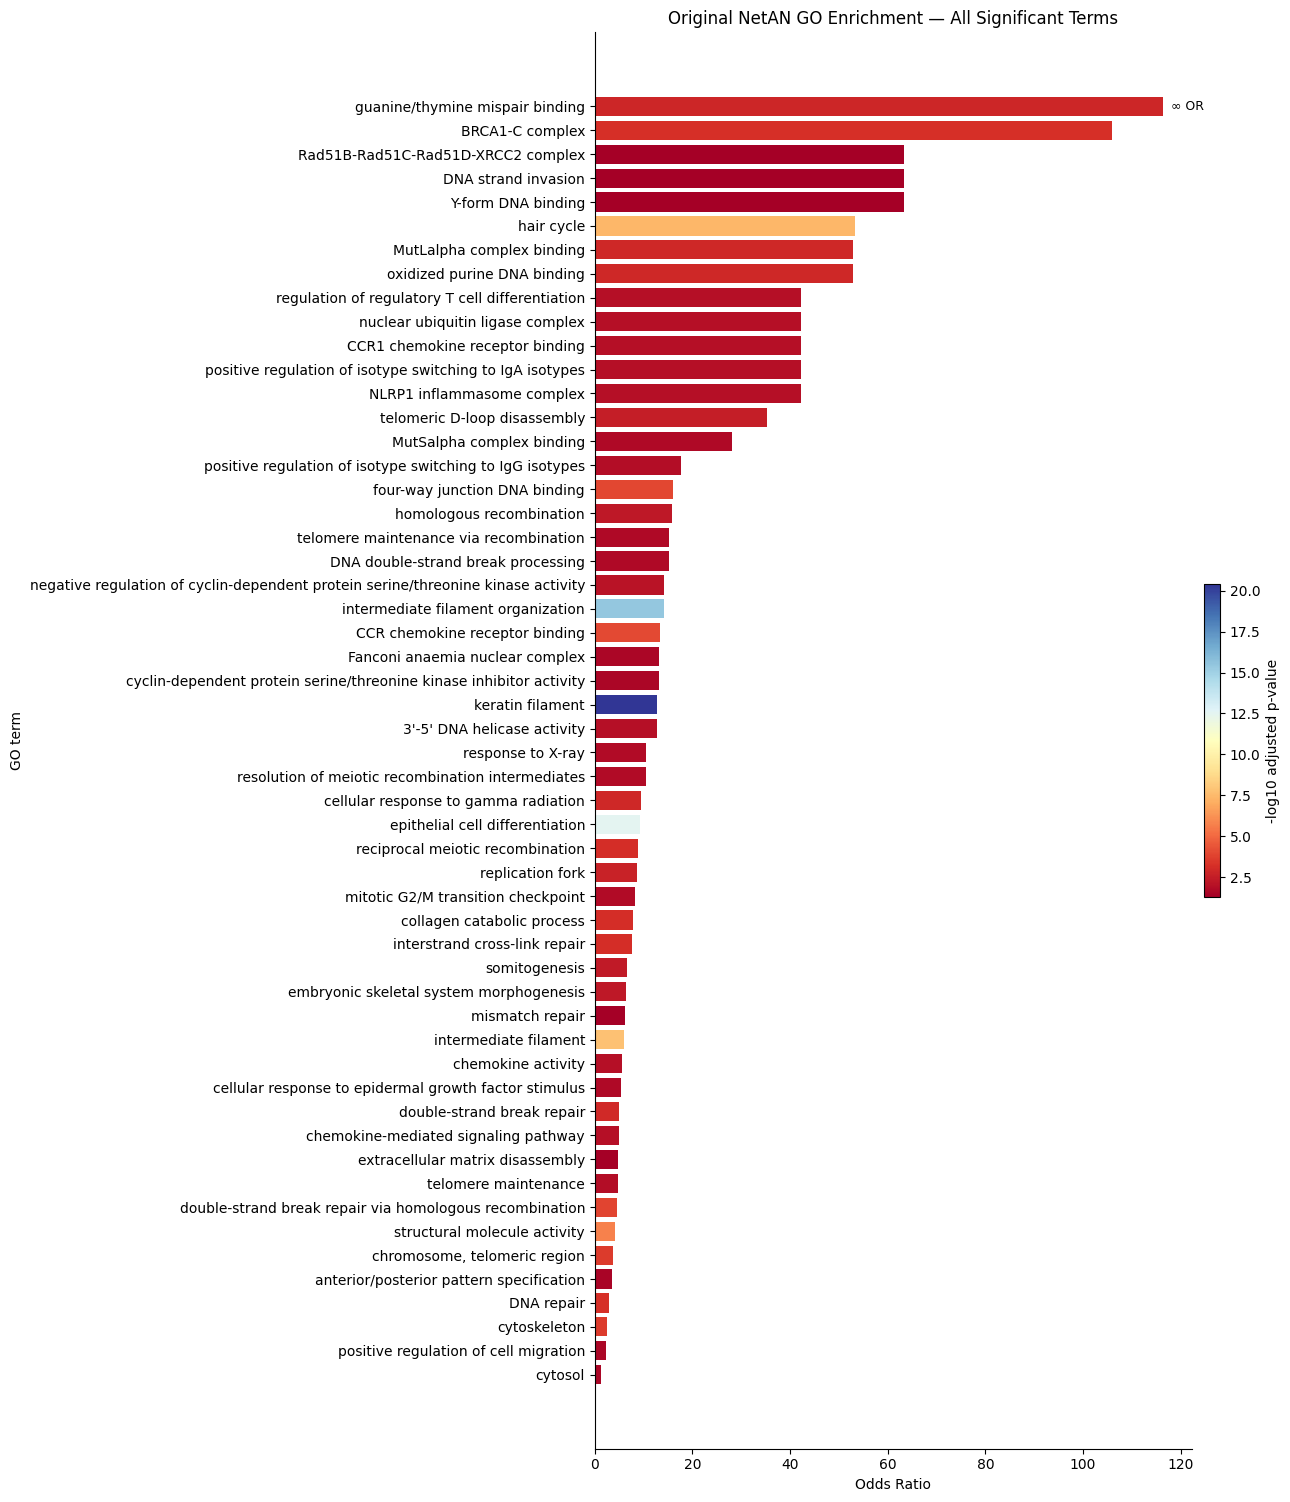

Full GO figure saved:
/Users/gorgeous_jane/Documents/GitHub/NetAn-Breast-Cancer-geneset-Analysis/figures/original_netan/Original_NetAN_GO_All_Significant.png


In [20]:
# ============================================================
# Full Original NetAN GO enrichment
# All significant GO terms
# Infinite OR handled for visualization only
# ============================================================

go_full_plot = go_full.copy()

# Identify infinite odds ratios BEFORE sorting
inf_mask = ~np.isfinite(go_full_plot["OR"])

print("GO terms with infinite OR:", inf_mask.sum())

# Largest finite OR
max_finite_or = go_full_plot.loc[
    np.isfinite(go_full_plot["OR"]),
    "OR"
].max()

print("Largest finite OR:", max_finite_or)

# Keep the original OR untouched
go_full_plot["OR_plot"] = go_full_plot["OR"]

# Replace infinity only for plotting
go_full_plot.loc[
    inf_mask,
    "OR_plot"
] = max_finite_or * 1.10

# Store the infinite term name before sorting
infinite_terms = go_full_plot.loc[
    inf_mask
].index.tolist()

# Sort for plotting
go_full_plot = go_full_plot.sort_values(
    "OR_plot",
    ascending=True
)

# ============================================================
# Plot
# ============================================================

fig_height = max(12, len(go_full_plot) * 0.28)

fig, ax = plt.subplots(
    figsize=(13, fig_height)
)

norm = plt.Normalize(
    go_full_plot["neg_log10_padj"].min(),
    go_full_plot["neg_log10_padj"].max()
)

colors = plt.cm.RdYlBu(
    norm(go_full_plot["neg_log10_padj"])
)

bars = ax.barh(
    go_full_plot.index,
    go_full_plot["OR_plot"],
    color=colors
)

ax.set_xlabel("Odds Ratio")
ax.set_ylabel("GO term")
ax.set_title(
    "Original NetAN GO Enrichment — All Significant Terms"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Colourbar
sm = plt.cm.ScalarMappable(
    cmap=plt.cm.RdYlBu,
    norm=norm
)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    fraction=0.025,
    pad=0.02
)

cbar.set_label("-log10 adjusted p-value")

# Mark infinite OR terms
for i, term in enumerate(go_full_plot.index):
    if term in infinite_terms:
        ax.text(
            go_full_plot.loc[term, "OR_plot"],
            i,
            "  ∞ OR",
            va="center",
            fontsize=9
        )

plt.tight_layout()

full_go_figure = (
    FIGURE_DIR /
    "Original_NetAN_GO_All_Significant.png"
)

plt.savefig(
    full_go_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Full GO figure saved:")
print(full_go_figure)

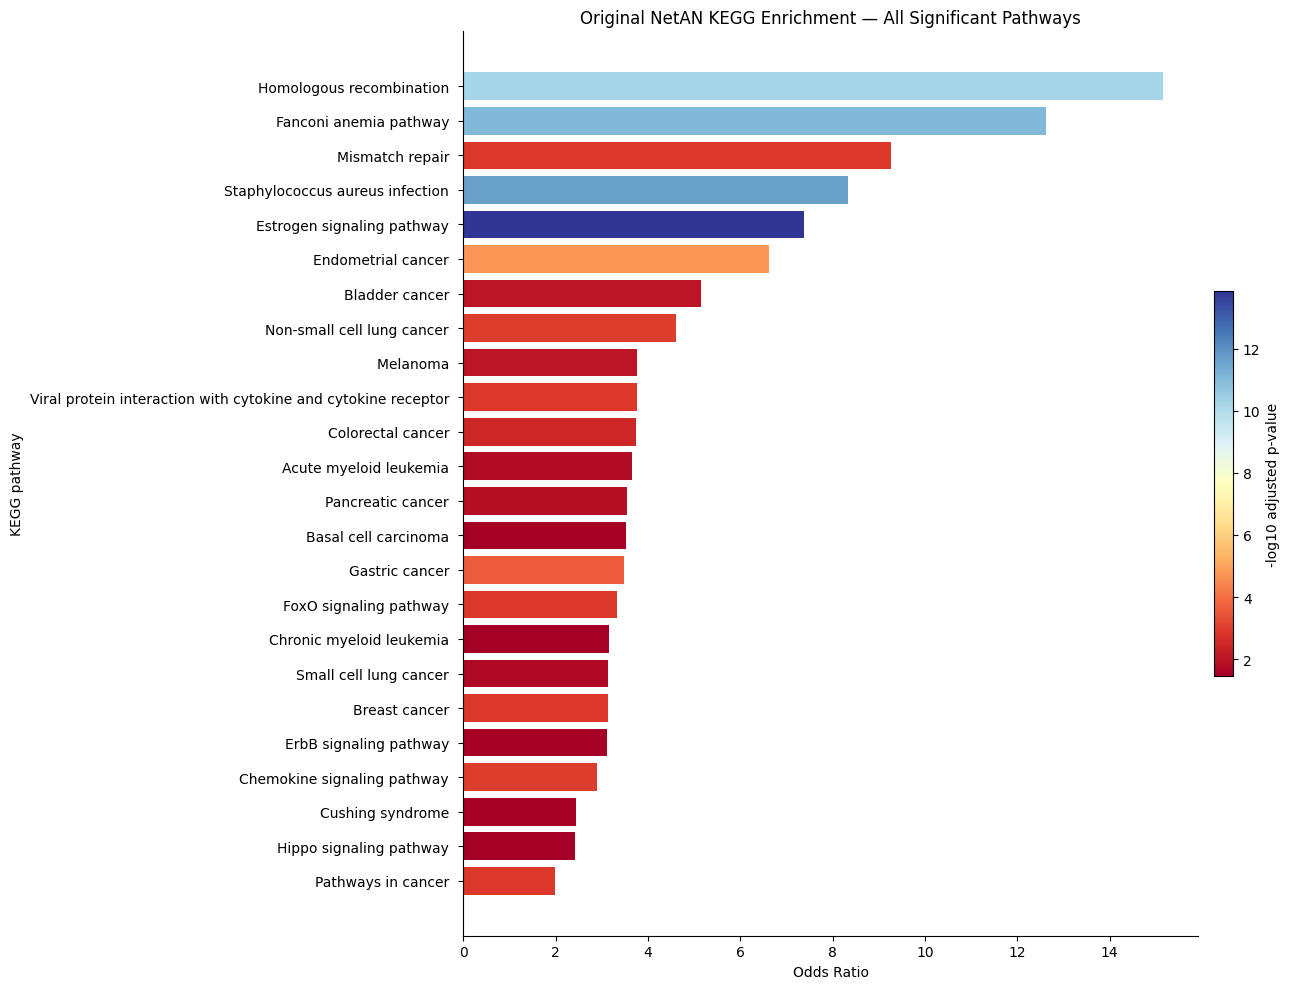

Full KEGG figure saved:
/Users/gorgeous_jane/Documents/GitHub/NetAn-Breast-Cancer-geneset-Analysis/figures/original_netan/Original_NetAN_KEGG_All_Significant.png


In [21]:
# ============================================================
# Full Original NetAN KEGG enrichment
# All significant KEGG pathways
# ============================================================

kegg_full_plot = kegg_full.copy()

# Sort by odds ratio
kegg_full_plot = kegg_full_plot.sort_values(
    "OR",
    ascending=True
)

# Figure height
fig_height = max(
    10,
    len(kegg_full_plot) * 0.40
)

fig, ax = plt.subplots(
    figsize=(13, fig_height)
)

# Colour scale based on adjusted p-value
norm = plt.Normalize(
    kegg_full_plot["neg_log10_padj"].min(),
    kegg_full_plot["neg_log10_padj"].max()
)

colors = plt.cm.RdYlBu(
    norm(kegg_full_plot["neg_log10_padj"])
)

ax.barh(
    kegg_full_plot.index,
    kegg_full_plot["OR"],
    color=colors
)

ax.set_xlabel("Odds Ratio")
ax.set_ylabel("KEGG pathway")
ax.set_title(
    "Original NetAN KEGG Enrichment — All Significant Pathways"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Colourbar
sm = plt.cm.ScalarMappable(
    cmap=plt.cm.RdYlBu,
    norm=norm
)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    fraction=0.025,
    pad=0.02
)

cbar.set_label(
    "-log10 adjusted p-value"
)

plt.tight_layout()

full_kegg_figure = (
    FIGURE_DIR /
    "Original_NetAN_KEGG_All_Significant.png"
)

plt.savefig(
    full_kegg_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Full KEGG figure saved:")
print(full_kegg_figure)